In [1]:
import numpy as np
import functools
from core_periphery_bandit import compute_oracle_table, compute_rule_value, configure_threads

configure_threads(8)

# ------------------------------------------------------------------
# Check A: independent brute-force cross-check, via a totally
# different code path (pure-Python recursion + memoization, no arrays,
# no numba) against the numba array-based backward induction.
# ------------------------------------------------------------------
def brute_force_oracle_value(mu1_star, mu2_star, v, p, T):
    @functools.lru_cache(maxsize=None)
    def V(t, n2):
        if t == T + 1:
            return 0.0
        m2 = mu2_star * (1 - np.exp(-v * n2))
        val_core = mu1_star + V(t + 1, n2)
        val_peri = m2 + V(t + 1, n2 + 1)
        best_avail = max(val_core, val_peri)
        unavail_val = m2 + V(t + 1, n2 + 1)
        return p * unavail_val + (1 - p) * best_avail
    return V(1, 0)

T_small = 8
print("Check A: independent brute-force vs numba DP")
for mu1_star, mu2_star, v, p in [(0.6, 0.75, 0.05, 0.85), (0.75, 0.6, 0.05, 0.5), (0.5, 0.9, 0.1, 0.3)]:
    v_bf = brute_force_oracle_value(mu1_star, mu2_star, v, p, T_small)
    v_dp = compute_rule_value(mu1_star, mu2_star, v, p, T_small, 0)
    print(f"  mu1={mu1_star}, mu2={mu2_star}: brute-force={v_bf:.6f}  numba-DP={v_dp:.6f}  diff={abs(v_bf-v_dp):.2e}")
    assert abs(v_bf - v_dp) < 1e-8, "MISMATCH: independent implementations disagree"
print("  PASS\n")

# ------------------------------------------------------------------
# Check B: exhaustive full-table cross-check (every reachable state,
# not just the starting state) between the two independent implementations.
# ------------------------------------------------------------------
mu1_star, mu2_star, v, p = 0.6, 0.75, 0.02, 0.85
T_mid = 60

@functools.lru_cache(maxsize=None)
def V_rec(t, n2):
    if t == T_mid + 1:
        return 0.0
    m2 = mu2_star * (1 - np.exp(-v * n2))
    val_core = mu1_star + V_rec(t + 1, n2)
    val_peri = m2 + V_rec(t + 1, n2 + 1)
    best_avail = max(val_core, val_peri)
    unavail_val = m2 + V_rec(t + 1, n2 + 1)
    return p * unavail_val + (1 - p) * best_avail

V_next = np.zeros(T_mid + 2)
V_full = np.zeros((T_mid + 2, T_mid + 2))
for t in range(T_mid, 0, -1):
    V_cur = np.zeros(T_mid + 2)
    for n2 in range(0, t + 1):
        m2 = mu2_star * (1 - np.exp(-v * n2))
        val_core = mu1_star + V_next[n2]
        val_peri = m2 + V_next[min(n2 + 1, T_mid + 1)]
        best_avail = max(val_core, val_peri)
        unavail_val = m2 + V_next[min(n2 + 1, T_mid + 1)]
        V_cur[n2] = p * unavail_val + (1 - p) * best_avail
    V_full[t, :] = V_cur
    V_next = V_cur

max_diff = 0.0
n_checked = 0
for t in range(1, T_mid + 1):
    for n2 in range(0, t + 1):
        max_diff = max(max_diff, abs(V_rec(t, n2) - V_full[t, n2]))
        n_checked += 1

print(f"Check B: exhaustive cross-check, {n_checked} states")
print(f"  max |difference| across ALL reachable states: {max_diff:.2e}")
assert max_diff < 1e-8, "MISMATCH somewhere in the full table"
print("  PASS\n")

# ------------------------------------------------------------------
# Check C: oracle must dominate EVERY fixed-bias randomized policy,
# not just the two named extremes (always_core / always_periphery).
# Sweeps q = P(choose core | available), same q at every state.
# ------------------------------------------------------------------
def value_randomized_fixed_bias(mu1_star, mu2_star, v, p, T, q):
    V_next = np.zeros(T + 2)
    for t in range(T, 0, -1):
        V_cur = np.zeros(T + 2)
        for n2 in range(0, t + 1):
            m2 = mu2_star * (1 - np.exp(-v * n2))
            val_core = mu1_star + V_next[n2]
            val_peri = m2 + V_next[min(n2 + 1, T + 1)]
            mixed = q * val_core + (1 - q) * val_peri
            unavail_val = m2 + V_next[min(n2 + 1, T + 1)]
            V_cur[n2] = p * unavail_val + (1 - p) * mixed
        V_next = V_cur
    return V_next[0]

mu1_star, mu2_star, v, p = 0.6, 0.75, 0.01, 0.85
T_full = 2000
v_oracle = compute_rule_value(mu1_star, mu2_star, v, p, T_full, 0)

print("Check C: oracle vs. every fixed-bias policy, q in [0,1]")
worst = None
for q in np.linspace(0, 1, 51):
    v_q = value_randomized_fixed_bias(mu1_star, mu2_star, v, p, T_full, q)
    if v_q > v_oracle + 1e-6:
        worst = (q, v_q)
print(f"  oracle value: {v_oracle:.4f}")
print("  any q beats oracle?", worst if worst else "No (oracle dominates all 51 tested biases)")
assert worst is None, f"MISMATCH: q={worst[0]} beats the oracle"
print("  PASS")

Check A: independent brute-force vs numba DP
  mu1=0.6, mu2=0.75: brute-force=1.401696  numba-DP=1.401696  diff=0.00e+00
  mu1=0.75, mu2=0.6: brute-force=3.195145  numba-DP=3.195145  diff=0.00e+00
  mu1=0.5, mu2=0.9: brute-force=3.003935  numba-DP=3.003935  diff=0.00e+00
  PASS

Check B: exhaustive cross-check, 1890 states
  max |difference| across ALL reachable states: 0.00e+00
  PASS

Check C: oracle vs. every fixed-bias policy, q in [0,1]
  oracle value: 1424.6244
  any q beats oracle? No (oracle dominates all 51 tested biases)
  PASS


                Greedy: final regret =   13.189 +/-   2.778   (25.50s)
       ETC (m=T^1/4=8): final regret =   13.242 +/-   2.656   (10.89s)
      ETC (m=T^1/3=17): final regret =   13.242 +/-   2.656   (0.16s)
      ETC (m=T^1/2=71): final regret =   13.457 +/-   2.331   (0.22s)
                  UCB1: final regret =   67.492 +/-   6.802   (0.21s)
              Thompson: final regret =   13.240 +/-   2.730   (0.31s)


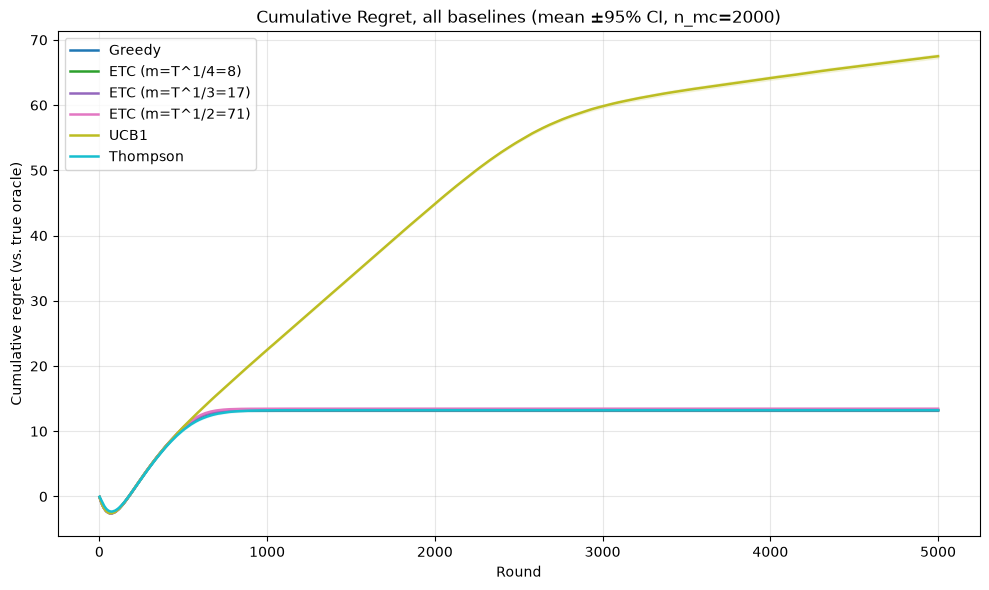

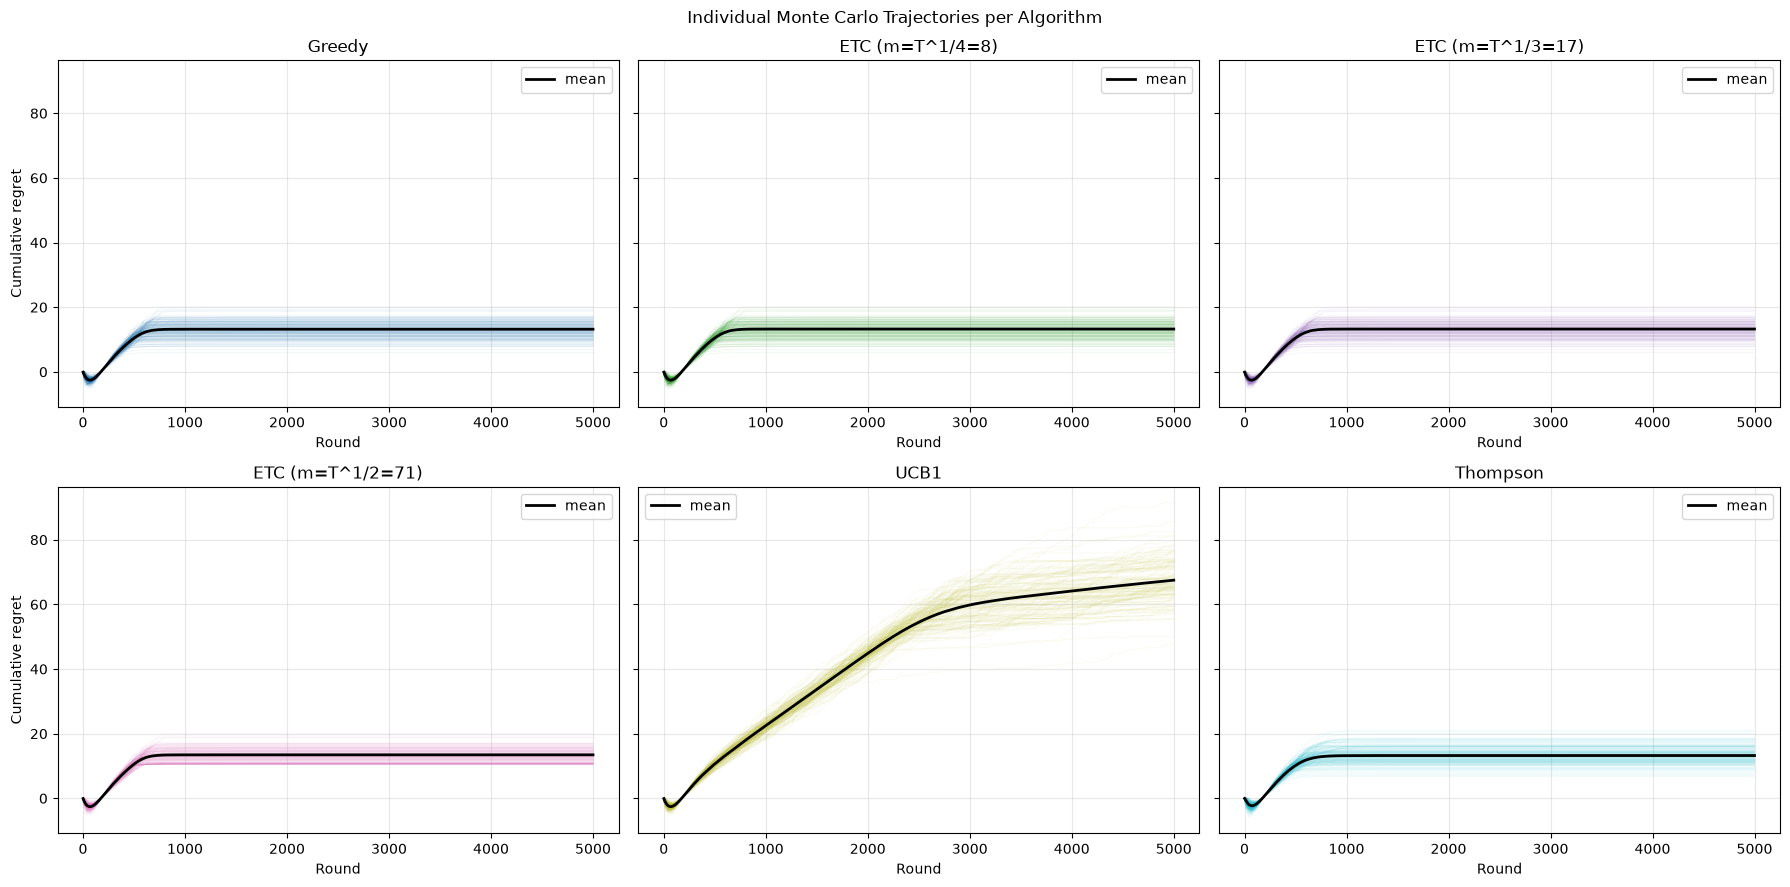

In [2]:
import time
import numpy as np
import matplotlib.pyplot as plt
from core_periphery_bandit import (
    compute_oracle_table, monte_carlo, configure_threads,
    POLICY_GREEDY, POLICY_ETC, POLICY_UCB1, POLICY_THOMPSON,
)

configure_threads(8)

# ---- scenario ----
mu1_star, mu2_star, v, p, sigma = 0.6, 0.75, 0.01, 0.85, 0.2
T, n_mc = 5000, 2000

table = compute_oracle_table(mu1_star, mu2_star, v, p, T)  # once per parameter set

m4 = int(round(T ** 0.25))
m3 = int(round(T ** (1/3)))
m2 = int(round(T ** 0.5))

policies = [
    (POLICY_GREEDY,   "Greedy",              {}),
    (POLICY_ETC,      f"ETC (m=T^1/4={m4})", dict(explore_m=m4)),
    (POLICY_ETC,      f"ETC (m=T^1/3={m3})", dict(explore_m=m3)),
    (POLICY_ETC,      f"ETC (m=T^1/2={m2})", dict(explore_m=m2)),
    (POLICY_UCB1,     "UCB1",                {}),
    (POLICY_THOMPSON, "Thompson",            {}),
]

results = {}
for pid, name, extra in policies:
    t0 = time.time()
    mean_r, std_r, frac2, final_r, sample_r = monte_carlo(
        pid, n_mc, T, mu1_star, mu2_star, v, p, sigma, 2026, table, n_sample=150, **extra
    )
    results[name] = dict(mean=mean_r, std=std_r, frac2=frac2, final=final_r, sample=sample_r)
    print(f"{name:>22s}: final regret = {final_r.mean():8.3f} +/- {final_r.std():7.3f}   ({time.time()-t0:.2f}s)")

# ---- plot: mean cumulative regret, +/- 95% CI ----
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(1, T + 1)
colors = plt.cm.tab10(np.linspace(0, 1, len(results)))
for (name, res), color in zip(results.items(), colors):
    se = res["std"] / np.sqrt(n_mc)
    ax.plot(x, res["mean"], label=name, color=color, lw=1.8)
    ax.fill_between(x, res["mean"] - 1.96*se, res["mean"] + 1.96*se, color=color, alpha=0.12)
ax.set_xlabel("Round")
ax.set_ylabel("Cumulative regret (vs. true oracle)")
ax.set_title(f"Cumulative Regret, all baselines (mean $\\pm$95% CI, n_mc={n_mc})")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ---- plot: individual trajectories per algorithm (one subplot each) ----
fig, axes = plt.subplots(2, 3, figsize=(18, 9), sharey=True)
for ax, ((name, res), color) in zip(axes.flat, zip(results.items(), colors)):
    for i in range(res["sample"].shape[0]):
        ax.plot(x, res["sample"][i, :], color=color, alpha=0.06, lw=0.7)
    ax.plot(x, res["mean"], color="black", lw=2.0, label="mean")
    ax.set_title(name)
    ax.set_xlabel("Round")
    ax.grid(alpha=0.3)
    ax.legend()
axes[0,0].set_ylabel("Cumulative regret")
axes[1,0].set_ylabel("Cumulative regret")
fig.suptitle("Individual Monte Carlo Trajectories per Algorithm")
plt.tight_layout()
plt.show()

In [3]:
import time
import numpy as np
import matplotlib.pyplot as plt
from core_periphery_bandit import (
    compute_oracle_table, monte_carlo, configure_threads,
    POLICY_GREEDY, POLICY_ETC, POLICY_UCB1, POLICY_THOMPSON,
)

configure_threads(8)

# ---- fixed instances ----
SIGMA = 0.2
INSTANCES = {
    "periphery better (mu2*=0.75 > mu1*=0.6)": dict(mu1_star=0.6, mu2_star=0.75),
    "periphery worse (mu2*=0.6 < mu1*=0.75)":  dict(mu1_star=0.75, mu2_star=0.6),
}

# ---- sweep grid ----
T, n_mc = 5000, 2000
V_GRID = np.geomspace(0.0002, 0.05, 8)   # v*T spans ~1 (barely resolves) to ~250 (resolves almost instantly)
P_GRID = np.linspace(0.1, 0.9, 8)

POLICIES = {
    "Greedy":            (POLICY_GREEDY, {}),
    "ETC (T^1/4)":       (POLICY_ETC, dict(explore_m=int(round(T**0.25)))),
    "ETC (T^1/3)":       (POLICY_ETC, dict(explore_m=int(round(T**(1/3))))),
    "ETC (T^1/2)":       (POLICY_ETC, dict(explore_m=int(round(T**0.5)))),
    "UCB1":              (POLICY_UCB1, {}),
    "Thompson":          (POLICY_THOMPSON, {}),
}

def run_sweep(mu1_star, mu2_star, v_grid, p_grid, policies, T, n_mc, sigma, base_seed=1000):
    n_v, n_p = len(v_grid), len(p_grid)
    grids = {name: np.zeros((n_v, n_p)) for name in policies}

    t0 = time.time()
    for i, v in enumerate(v_grid):
        for j, p in enumerate(p_grid):
            table = compute_oracle_table(mu1_star, mu2_star, v, p, T)  # fresh per grid point -- oracle depends on (v,p)
            for name, (pid, extra) in policies.items():
                mean_r, std_r, frac2, final_r, sample_r = monte_carlo(
                    pid, n_mc, T, mu1_star, mu2_star, v, p, sigma, base_seed, table, n_sample=2, **extra
                )
                grids[name][i, j] = final_r.mean()
        print(f"  v={v:.5f} done ({i+1}/{n_v} rows, {time.time()-t0:.1f}s elapsed)")
    print(f"sweep finished in {time.time()-t0:.1f}s")
    return grids

all_results = {}
for instance_name, inst in INSTANCES.items():
    print(f"\n=== {instance_name} ===")
    all_results[instance_name] = run_sweep(
        inst["mu1_star"], inst["mu2_star"], V_GRID, P_GRID, POLICIES, T, n_mc, SIGMA
    )


=== periphery better (mu2*=0.75 > mu1*=0.6) ===
  v=0.00020 done (1/8 rows, 15.3s elapsed)
  v=0.00044 done (2/8 rows, 28.0s elapsed)
  v=0.00097 done (3/8 rows, 41.8s elapsed)
  v=0.00213 done (4/8 rows, 55.7s elapsed)
  v=0.00469 done (5/8 rows, 68.0s elapsed)
  v=0.01032 done (6/8 rows, 80.6s elapsed)
  v=0.02272 done (7/8 rows, 93.9s elapsed)
  v=0.05000 done (8/8 rows, 106.8s elapsed)
sweep finished in 106.8s

=== periphery worse (mu2*=0.6 < mu1*=0.75) ===
  v=0.00020 done (1/8 rows, 13.3s elapsed)
  v=0.00044 done (2/8 rows, 26.2s elapsed)
  v=0.00097 done (3/8 rows, 38.6s elapsed)
  v=0.00213 done (4/8 rows, 51.4s elapsed)
  v=0.00469 done (5/8 rows, 63.9s elapsed)
  v=0.01032 done (6/8 rows, 77.0s elapsed)
  v=0.02272 done (7/8 rows, 89.1s elapsed)
  v=0.05000 done (8/8 rows, 101.7s elapsed)
sweep finished in 101.7s


saved sweep_periphery_better.png


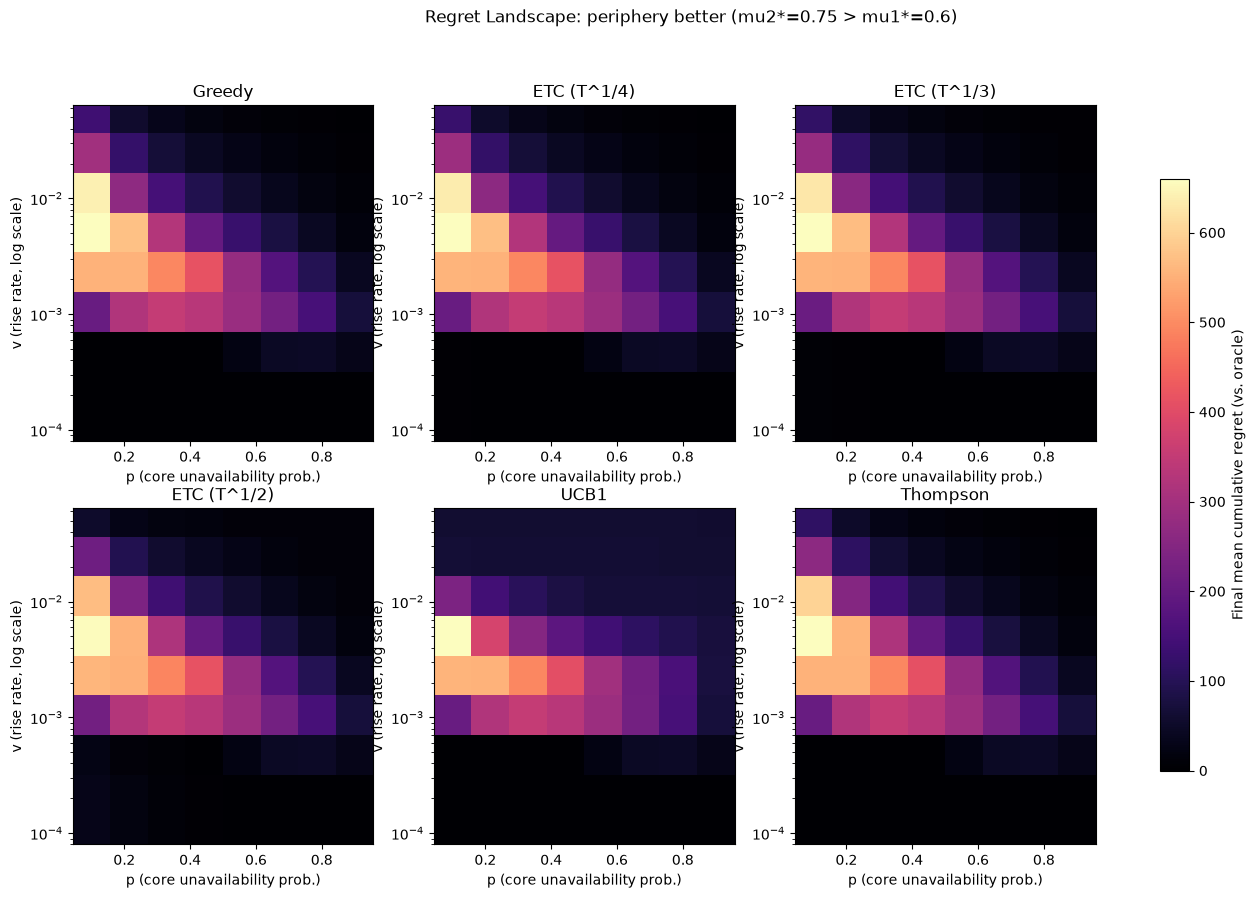

saved sweep_periphery_worse.png


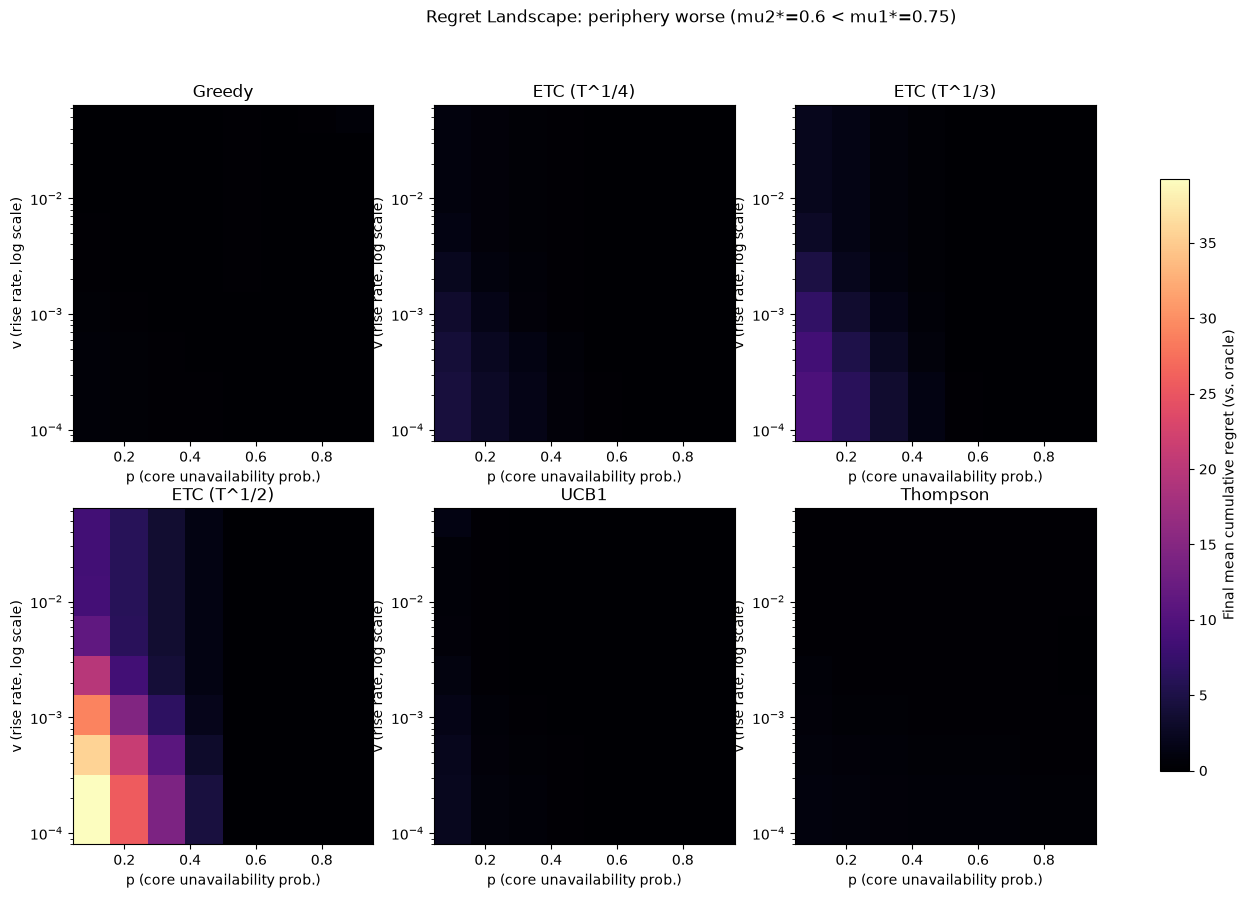

In [4]:
def plot_instance_heatmaps(instance_name, grids, v_grid, p_grid, outpath=None):
    n_policies = len(grids)
    ncols = 3
    nrows = int(np.ceil(n_policies / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.5*ncols, 4.8*nrows), squeeze=False)

    vmax = max(g.max() for g in grids.values())

    for idx, (name, grid) in enumerate(grids.items()):
        ax = axes[idx // ncols, idx % ncols]
        im = ax.pcolormesh(p_grid, v_grid, grid, shading="auto", vmin=0, vmax=vmax, cmap="magma")
        ax.set_yscale("log")
        ax.set_xlabel("p (core unavailability prob.)")
        ax.set_ylabel("v (rise rate, log scale)")
        ax.set_title(name)

    # hide unused subplots
    for idx in range(n_policies, nrows*ncols):
        axes[idx // ncols, idx % ncols].axis("off")

    fig.colorbar(im, ax=axes, label="Final mean cumulative regret (vs. oracle)", shrink=0.8)
    fig.suptitle(f"Regret Landscape: {instance_name}")
    if outpath:
        fig.savefig(outpath, dpi=150, bbox_inches="tight")
        print(f"saved {outpath}")
    plt.show()

for instance_name, grids in all_results.items():
    safe_name = instance_name.split("(")[0].strip().replace(" ", "_")
    plot_instance_heatmaps(instance_name, grids, V_GRID, P_GRID, outpath=f"sweep_{safe_name}.png")

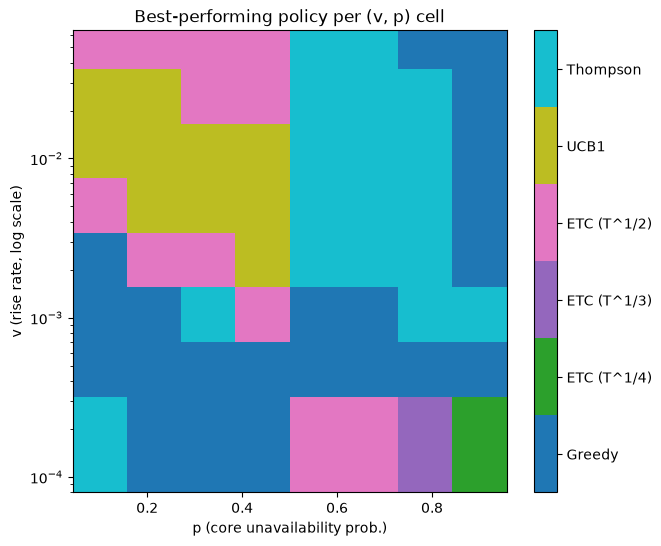

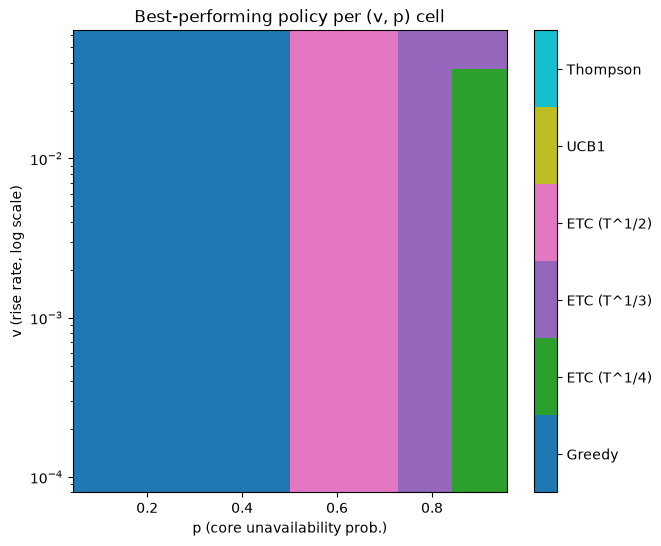

In [5]:
def plot_winner_map(all_results_for_instance, v_grid, p_grid, outpath=None):
    names = list(all_results_for_instance.keys())
    stacked = np.stack([all_results_for_instance[n] for n in names], axis=0)  # (n_policy, n_v, n_p)
    winner_idx = np.argmin(stacked, axis=0)  # index of best (lowest regret) policy per cell

    fig, ax = plt.subplots(figsize=(7, 6))
    cmap = plt.get_cmap("tab10", len(names))
    im = ax.pcolormesh(p_grid, v_grid, winner_idx, shading="auto", cmap=cmap, vmin=-0.5, vmax=len(names)-0.5)
    ax.set_yscale("log")
    ax.set_xlabel("p (core unavailability prob.)")
    ax.set_ylabel("v (rise rate, log scale)")
    ax.set_title("Best-performing policy per (v, p) cell")
    cbar = fig.colorbar(im, ax=ax, ticks=range(len(names)))
    cbar.ax.set_yticklabels(names)
    if outpath:
        fig.savefig(outpath, dpi=150, bbox_inches="tight")
    plt.show()

for instance_name, grids in all_results.items():
    plot_winner_map(grids, V_GRID, P_GRID, outpath=f"winner_map_{instance_name[:10]}.png")